# Feature Engineering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
%matplotlib inline

### Train Data Feature Engineering

In [2]:
df_train = pd.read_csv('./data/train_new.csv')
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S


In [3]:
def get_title(name):
    title_search = re.search(' ([A-Za-z]+)\.', name)
    if title_search:
        return title_search.group(1)
    return ''
df_train['Title'] = df_train.Name.apply(get_title)
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,Mr


In [4]:
df_train.Title.value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64

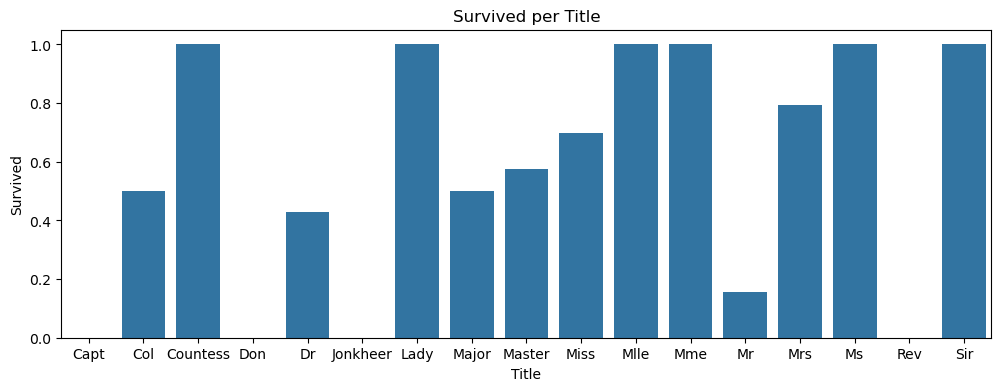

In [5]:
tt_sur_mean = df_train.groupby('Title')['Survived'].mean().reset_index()
plt.figure(figsize=(12,4))
sns.barplot(x = 'Title', y = 'Survived', data = tt_sur_mean)
plt.title('Survived per Title')
plt.show()

In [6]:
rare_map = list(df_train.Title.value_counts().keys())[4:]
df_train.Title = df_train.Title.replace(rare_map, 'Rare')

In [7]:
df_train['FamilySize'] = df_train['SibSp'] + df_train['Parch'] + 1
df_train['FamilySize'].value_counts()

FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

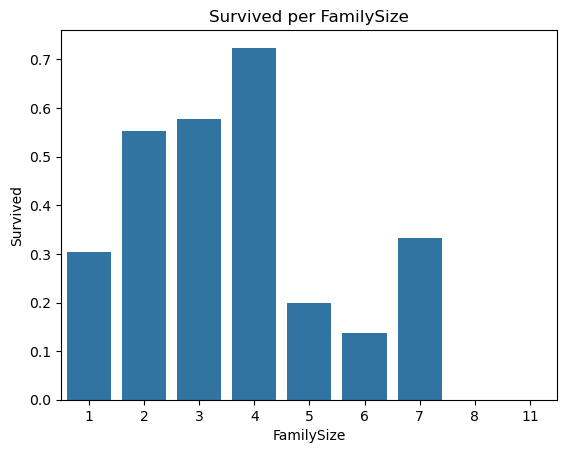

In [8]:
fs_sur_mean = df_train.groupby('FamilySize')['Survived'].mean().reset_index()
plt.figure()
sns.barplot(x='FamilySize', y='Survived', data=fs_sur_mean)
plt.title('Survived per FamilySize')
plt.show()

In [9]:
bins = [0, 1, 4, 12]
labels = ['Single', 'Small', 'Big']

df_train['FamilyCategory'] = pd.cut(
    df_train['FamilySize'], 
    bins=bins, 
    labels=labels, 
    right=True,
    include_lowest=True
)

df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,FamilyCategory
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,Mr,2,Small
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs,2,Small
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,Miss,1,Single
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,Mrs,2,Small
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,Mr,1,Single


In [44]:
df_train['FamilyCategory'].value_counts()

FamilyCategory
Single    537
Small     292
Big        62
Name: count, dtype: int64

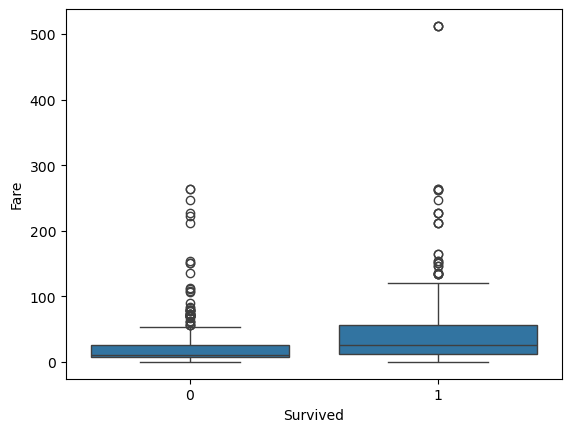

In [10]:
plt.figure()
sns.boxplot(x = 'Survived', y = 'Fare', data = df_train)
plt.show()

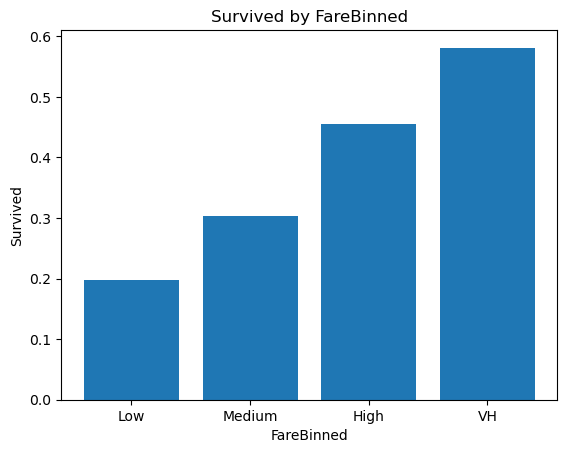

In [11]:
bins = df_train['Fare'].quantile([0, 0.25, 0.5, 0.75, 1]).tolist()
labels = ['Low', 'Medium', 'High', 'VH']
df_train['FareBinned'] = pd.cut(
    df_train['Fare'],
    bins = bins,
    labels = labels,
    include_lowest = True,
    right = True
)
fare_mean = df_train.groupby('FareBinned', observed=True)['Survived'].mean().reset_index()
plt.figure()
plt.bar(fare_mean['FareBinned'], fare_mean['Survived'])
plt.title('Survived by FareBinned')
plt.xlabel('FareBinned')
plt.ylabel('Survived')
plt.show()

In [12]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,FamilyCategory,FareBinned
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,Mr,2,Small,Low
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs,2,Small,VH
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,Miss,1,Single,Medium
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,Mrs,2,Small,VH
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,Mr,1,Single,Medium


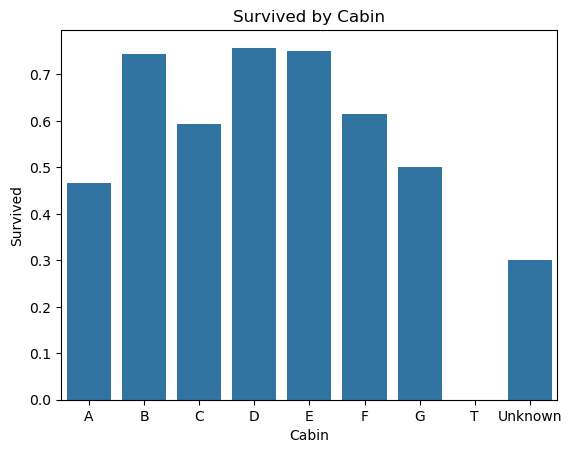

In [13]:
cabin_mean = df_train.groupby('Cabin', observed = True)['Survived'].mean().reset_index()
plt.figure()
sns.barplot(x = 'Cabin', y = 'Survived', data = cabin_mean)
plt.title('Survived by Cabin')
plt.show()

In [14]:
def map_cabin_group(c):
    if c in ['B', 'D', 'E']:
        return 'HighDeck'
    elif c in ['A', 'C', 'F', 'G']:
        return 'MidDeck'
    else:
        return 'Unknown'
        
df_train['CabinGroup'] = df_train['Cabin'].map(map_cabin_group)

In [15]:
bins = [0, 16, 60, 81] 
labels = ['Child', 'Adult', 'Elderly']
df_train['AgeGroup'] = pd.cut(
    df_train['Age'],
    bins = bins,
    labels = labels,
    right = True,
    include_lowest = True
)
df_train['AgeGroup'].value_counts()

AgeGroup
Adult      769
Child      100
Elderly     22
Name: count, dtype: int64

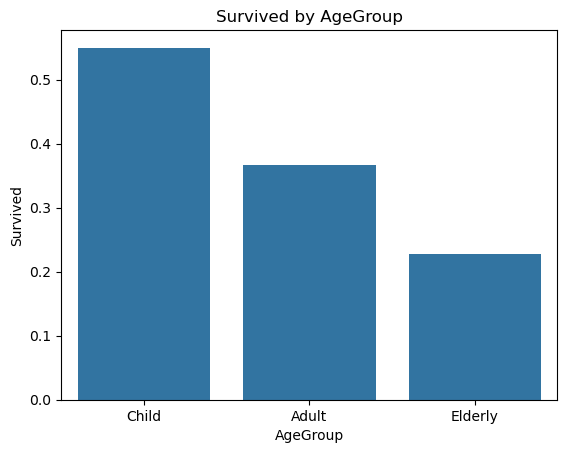

In [16]:
ag_mean = df_train.groupby('AgeGroup', observed = True)['Survived'].mean().reset_index()
plt.figure()
sns.barplot(x = 'AgeGroup', y = 'Survived', data = ag_mean)
plt.title('Survived by AgeGroup')
plt.show()

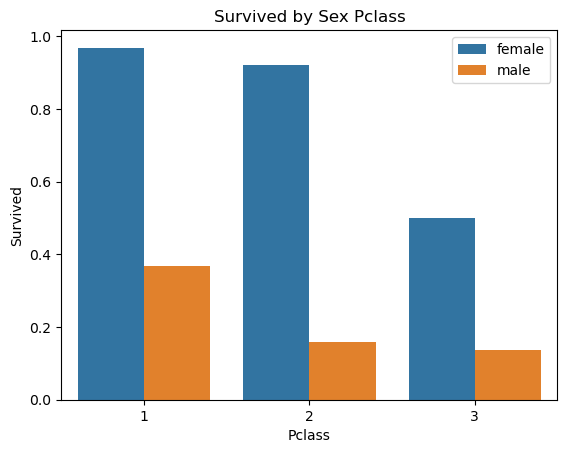

In [17]:
sex_pcl_mean = df_train.groupby(['Sex', 'Pclass'])['Survived'].mean().reset_index()
plt.figure()
sns.barplot(x = 'Pclass', y = 'Survived', hue = 'Sex', data = sex_pcl_mean)
plt.title('Survived by Sex Pclass')
plt.legend()
plt.show()

In [18]:
df_train['Sex_Pclass'] = df_train['Sex'].astype(str) + '_' + df_train['Pclass'].astype(str)
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,FamilyCategory,FareBinned,CabinGroup,AgeGroup,Sex_Pclass
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,Mr,2,Small,Low,Unknown,Adult,male_3
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs,2,Small,VH,MidDeck,Adult,female_1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,Miss,1,Single,Medium,Unknown,Adult,female_3
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,Mrs,2,Small,VH,MidDeck,Adult,female_1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,Mr,1,Single,Medium,Unknown,Adult,male_3


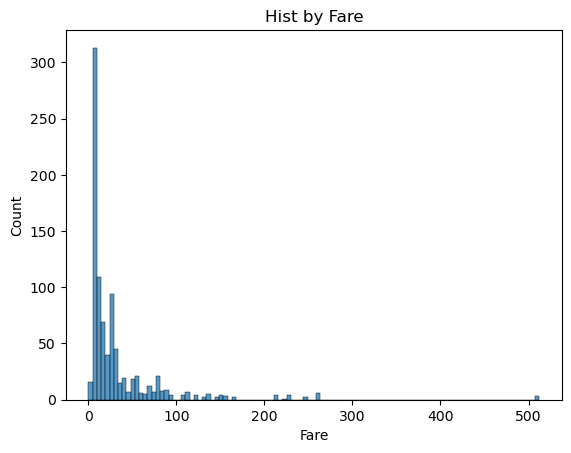

In [19]:
plt.figure()
sns.histplot(df_train['Fare'])
plt.title('Hist by Fare')
plt.show()

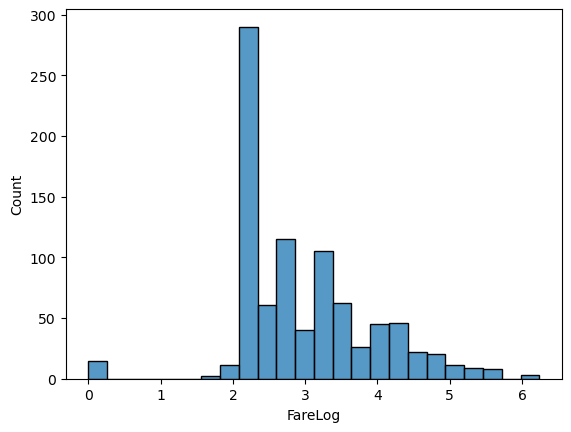

In [20]:
df_train['FareLog'] = np.log1p(df_train['Fare'])
plt.figure()
sns.histplot(df_train['FareLog'])
plt.show()

In [36]:
df_train['Age*Pclass'] = df_train['Age'] * df_train['Pclass']

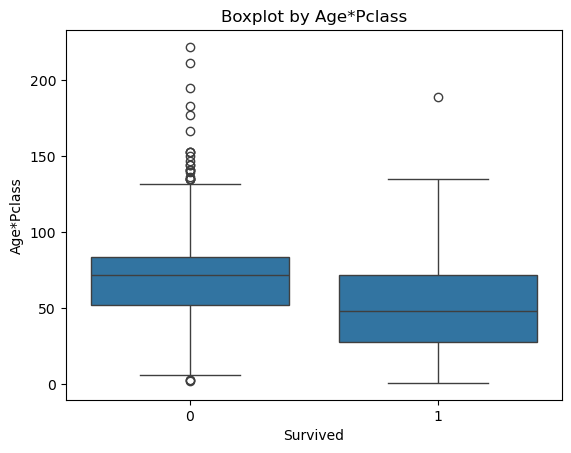

In [39]:
plt.figure()
sns.boxplot(x = df_train['Survived'], y = df_train['Age*Pclass'])
plt.title('Boxplot by Age*Pclass')
plt.show()

### Test Data Feature Engineering

In [22]:
df_test = pd.read_csv('./data/test_new.csv')
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Unknown,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,Unknown,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Unknown,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,Unknown,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,Unknown,S


In [23]:
df_test['Title'] = df_test['Name'].apply(get_title)
df_test.Title.value_counts()

Title
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: count, dtype: int64

In [24]:
rare_map = list(df_test.Title.value_counts().keys())[4:]
df_test.Title = df_test.Title.replace(rare_map, 'Rare')

In [25]:
df_test.Title.value_counts()

Title
Mr        240
Miss       78
Mrs        72
Master     21
Rare        7
Name: count, dtype: int64

In [26]:
df_test['FamilySize'] = df_test['SibSp'] + df_test['Parch'] + 1
df_test['FamilySize'].value_counts()

FamilySize
1     253
2      74
3      57
4      14
5       7
7       4
11      4
6       3
8       2
Name: count, dtype: int64

In [27]:
bins = [0, 1, 4, 12]
labels = ['Single', 'Small', 'Big']
df_test['FamilyCategory'] = pd.cut(
    df_test['FamilySize'],
    bins = bins,
    labels = labels,
    right = True,
    include_lowest = True
)

In [28]:
bins = df_train['Fare'].quantile([0, 0.25, 0.5, 0.75, 1]).tolist()
bins[4] = np.inf 
labels = ['Low', 'Medium', 'High', 'VH']
df_test['FareBinned'] = pd.cut(
    df_test['Fare'],
    bins = bins,
    labels = labels,
    include_lowest = True,
    right = True
)

In [29]:
df_test['CabinGroup'] = df_test['Cabin'].map(map_cabin_group)

In [30]:
bins = [0, 16, 60, 81] 
labels = ['Child', 'Adult', 'Elderly']
df_test['AgeGroup'] = pd.cut(
    df_test['Age'],
    bins = bins,
    labels = labels,
    right = True,
    include_lowest = True
)
df_test['AgeGroup'].value_counts()

AgeGroup
Adult      373
Child       34
Elderly     11
Name: count, dtype: int64

In [31]:
df_test['Sex_Pclass'] = df_test['Sex'].astype(str) + '_' + df_test['Pclass'].astype(str)

In [32]:
df_test['FareLog'] = np.log1p(df_test['Fare'])

In [40]:
df_test['Age*Pclass'] = df_test['Age'] * df_test['Pclass']

In [41]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,FamilyCategory,FareBinned,CabinGroup,AgeGroup,Sex_Pclass,FareLog,Age*Pclass
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Unknown,Q,Mr,1,Single,Low,Unknown,Adult,male_3,2.178064,103.5
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,Unknown,S,Mrs,2,Small,Low,Unknown,Adult,female_3,2.079442,141.0
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Unknown,Q,Mr,1,Single,Medium,Unknown,Elderly,male_2,2.369075,124.0
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,Unknown,S,Mr,1,Single,Medium,Unknown,Adult,male_3,2.268252,81.0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,Unknown,S,Mrs,3,Small,Medium,Unknown,Adult,female_3,2.586824,66.0


In [47]:
all_df = pd.concat([df_train, df_test], ignore_index=True)
ticket_counts = all_df['Ticket'].value_counts()
df_train['TicketFrequency'] = df_train['Ticket'].map(ticket_counts)
df_test['TicketFrequency'] = df_test['Ticket'].map(ticket_counts)
df_train[['Ticket', 'TicketFrequency', 'FamilySize']].head(10)

,Ticket,TicketFrequency,FamilySize
0,A/5 21171,1,2
1,PC 17599,2,2
2,STON/O2. 3101282,1,1
3,113803,2,2
4,373450,1,1
5,330877,1,1
6,17463,2,1
7,349909,5,5
8,347742,3,3
9,237736,2,2


In [48]:
df_train.to_csv('./data/train_fe.csv', index = False)
df_test.to_csv('./data/test_fe.csv', index = False)